<a href="https://colab.research.google.com/github/dwarcy/TopicosEspeciais_IA/blob/main/aula6_retrieval_augmented_generation_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6: Introdução a RAG (Retrieval-Augmented Generation)

Objetivos:

- Entender o pipeline completo de um sistema RAG
- Implementar:
  - Chunking
  - Geração de embeddings
  - Busca vetorial por similaridade
  - Geração de resposta condicionada ao contexto recuperado
- Analisar como a recuperação influencia a qualidade da resposta


Nesta aula vamos usar o seguinte roteiro prático:

1. Criar uma mini base de conhecimento (docs).
2. Fazer *chunking* (segmentação) para obter unidades recuperáveis.
3. Gerar embeddings e implementar uma busca vetorial simples.
4. Montar o *contexto* (augmentation) com os chunks mais relevantes.
5. Passar o contexto para um modelo gerador (generator) e obter uma resposta (*RAG completo*).


## 1) Setup do ambiente


In [20]:
# Se necessário, instale as seguintes dependências:
# !pip install -U sentence-transformers transformers torch scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 2) Mini Base de Conhecimento


In [73]:
# Mini base de conhecimento (exemplo didático).
# Dica: substitua por trechos do seu domínio (FAQ, políticas, docs, etc.).

docs = [
    {
        "id": "doc1",
        "text": '''
        Jane Austen foi uma romancista inglesa conhecida principalmente por seus seis romances, que implicitamente interpretam, criticam e comentam sobre a pequena nobreza rural inglesa no final do século XVIII.
        Os enredos de Austen frequentemente exploram a dependência das mulheres do casamento para a busca de posição social favorável e segurança econômica.
        Suas obras são críticas implícitas aos romances de sensibilidade da segunda metade do século XVIII e fazem parte da transição para o realismo literário do século XIX.
        Seu uso de comentários sociais, realismo, inteligência e ironia lhe rendeu elogios de críticos e acadêmicos.
        '''
    },
    {
        "id": "doc2",
        "text": '''
        John Ronald Reuel Tolkien, conhecido mundialmente como J R R Tolkien foi um escritor, professor universitário e filólogo britânico, nascido na atual África do Sul, que recebeu o título de doutor em Letras e Filologia pela Universidade de Liège e Dublin, em 1954.
        É autor das obras como O Hobbit, O Senhor dos Anéis e O Silmarillion.
        Em 28 de março de 1972, Tolkien foi nomeado Comendador da Ordem do Império Britânico pela Rainha Elizabeth II.
        '''
    },
    {
        "id": "doc3",
        "text": '''
        Victor-Marie Hugo foi um romancista, poeta, dramaturgo, ensaísta, artista, estadista e ativista pelos direitos humanos francês de grande atuação política em seu país.
        É autor de Les Misérables e de Notre-Dame de Paris, entre diversas outras obras clássicas de fama e renome mundial.
        '''
    }
]


## 3) Chunking (segmentação) - construção de contexto

Nesta aula, vamos usar sentenças como chunks (simples e didático).  
Em produção, você normalmente usa chunking por **tamanho** (tokens/caracteres) + **overlap**.


In [74]:
def split_sentences_pt(text: str) -> list[str]:
    # Segmentação simplificada (por ponto).
    return [s.strip() for s in text.split(".") if len(s.strip()) > 0]

rows = []
for doc in docs:
    sentences = split_sentences_pt(doc["text"])
    for sent in sentences:
        rows.append({
            "doc_id": doc["id"],
            "sentence": sent
        })

df = pd.DataFrame(rows)
df


,doc_id,sentence
0,doc1,Jane Austen foi uma romancista inglesa conheci...
1,doc1,Os enredos de Austen frequentemente exploram a...
2,doc1,Suas obras são críticas implícitas aos romance...
3,doc1,"Seu uso de comentários sociais, realismo, inte..."
4,doc2,"John Ronald Reuel Tolkien, conhecido mundialme..."
5,doc2,"É autor das obras como O Hobbit, O Senhor dos ..."
6,doc2,"Em 28 de março de 1972, Tolkien foi nomeado Co..."
7,doc3,"Victor-Marie Hugo foi um romancista, poeta, dr..."
8,doc3,É autor de Les Misérables e de Notre-Dame de P...


## 4) Gerar embeddings (Retriever, R do RAG)

Usaremos um modelo encoder-only do SentenceTransformers para gerar embeddings dos chunks.


In [75]:
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

sentences = df["sentence"].tolist()
embeddings = model_emb.encode(sentences)

df["embedding"] = list(embeddings)
df.head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,doc_id,sentence,embedding
0,doc1,Jane Austen foi uma romancista inglesa conheci...,"[-0.021164494, -0.014324701, 0.024238667, 0.05..."
1,doc1,Os enredos de Austen frequentemente exploram a...,"[0.020565238, 0.0034607472, -0.042643916, 0.04..."
2,doc1,Suas obras são críticas implícitas aos romance...,"[0.0053757518, -0.01994434, -0.00013239637, 0...."
3,doc1,"Seu uso de comentários sociais, realismo, inte...","[-0.007885407, 0.03989356, -0.116623215, 0.057..."
4,doc2,"John Ronald Reuel Tolkien, conhecido mundialme...","[0.019487439, 0.04413059, -0.058707148, -0.038..."


## 5) Busca vetorial por similaridade (R do RAG)

Implementação minimalista com similaridade cosseno.  
(Em produção, isso vai para um índice/banco vetorial: FAISS, Milvus, Pinecone, Weaviate, pgvector, etc.)


In [76]:
def retrieve(query: str, top_k: int = 3) -> pd.DataFrame:
    query_emb = model_emb.encode([query])
    matrix = np.vstack(df["embedding"].values)

    sims = cosine_similarity(query_emb, matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results

query = "Quem foi Jane Austen?"
retrieve(query, top_k=3)


,doc_id,sentence,embedding,score
0,doc1,Jane Austen foi uma romancista inglesa conheci...,"[-0.021164494, -0.014324701, 0.024238667, 0.05...",0.743658
1,doc1,Os enredos de Austen frequentemente exploram a...,"[0.020565238, 0.0034607472, -0.042643916, 0.04...",0.453360
6,doc2,"Em 28 de março de 1972, Tolkien foi nomeado Co...","[0.01689695, 0.044148337, -0.022067975, -0.003...",0.403157


## 6) Montando o contexto (Augmentation, A do RAG)

Agora agregamos os chunks recuperados em um bloco de texto que será injetado no prompt.


In [77]:
def build_context(query: str, top_k: int = 3) -> str:
    retrieved = retrieve(query, top_k)
    context = "\n".join(retrieved["sentence"].tolist())
    return context

query = "Qual livro Victor Hugo escreveu?"
context = build_context(query, top_k=3)
print(context)


Victor-Marie Hugo foi um romancista, poeta, dramaturgo, ensaísta, artista, estadista e ativista pelos direitos humanos francês de grande atuação política em seu país
É autor de Les Misérables e de Notre-Dame de Paris, entre diversas outras obras clássicas de fama e renome mundial
Suas obras são críticas implícitas aos romances de sensibilidade da segunda metade do século XVIII e fazem parte da transição para o realismo literário do século XIX


## 7) Parte gerativa (Generation, G do RAG)

Aqui usamos um modelo causal pequeno para fins didáticos. Troque o distilgpt2 para o gemma 3 para melhores resultados.


In [83]:
# model_name = "distilgpt2" # Modelo pequeno para teste rápido
model_name = "google/gemma-3-270m" # De melhor qualidade, mas download de 0.5G

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_gen = AutoModelForCausalLM.from_pretrained(model_name)

# distilgpt-2 não tem pad_token necessário para a geração
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-3-270m.
401 Client Error. (Request ID: Root=1-699f9dfd-5939ffa66562a8331f62c5fa;c8cefc53-14e5-4616-9916-d511a65bb476)

Cannot access gated repo for url https://huggingface.co/google/gemma-3-270m/resolve/main/config.json.
Access to model google/gemma-3-270m is restricted. You must have access to it and be authenticated to access it. Please log in.

## 8) Pipeline RAG simples

1. Recupera chunks (Retriever)  
2. Monta contexto (Augmentation)  
3. Gera resposta condicionada (Generator)


In [82]:
def rag_answer(query: str, top_k: int = 3, max_tokens: int = 150) -> str:
    context = build_context(query, top_k)

    prompt = f"""Responda à pergunta usando apenas o contexto abaixo.

Contexto:
{context}

Pergunta:
{query}

Resposta:
"""

    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

rag_answer("Quem é Jane Austen?", top_k=3)


'Responda à pergunta usando apenas o contexto abaixo.\n\nContexto:\nJane Austen foi uma romancista inglesa conhecida principalmente por seus seis romances, que implicitamente interpretam, criticam e comentam sobre a pequena nobreza rural inglesa no final do século XVIII\nOs enredos de Austen frequentemente exploram a dependência das mulheres do casamento para a busca de posição social favorável e segurança econômica\nEm 28 de março de 1972, Tolkien foi nomeado Comendador da Ordem do Império Britânico pela Rainha Elizabeth II\n\nPergunta:\nQuem é Jane Austen?\n\nResposta:\nJane Austen foi uma romancista inglesa conhecida principalmente por seus romances, que implicitamente interpretam, criticam e comentam sobre a pequena nobreza rural inglesa no final do século XVIII\nOs enredos de Austen frequentemente exploram a dependência das mulheres do casamento para a busca de posição social favorável e segurança econômica\nEm 28 de março de 1972, Tolkien foi nomeado Comendador da Ordem do Impéri

## 9) Visualizando similaridade (conexão com Embeddings)

Vamos projetar os embeddings em 2D com PCA para observar agrupamentos.


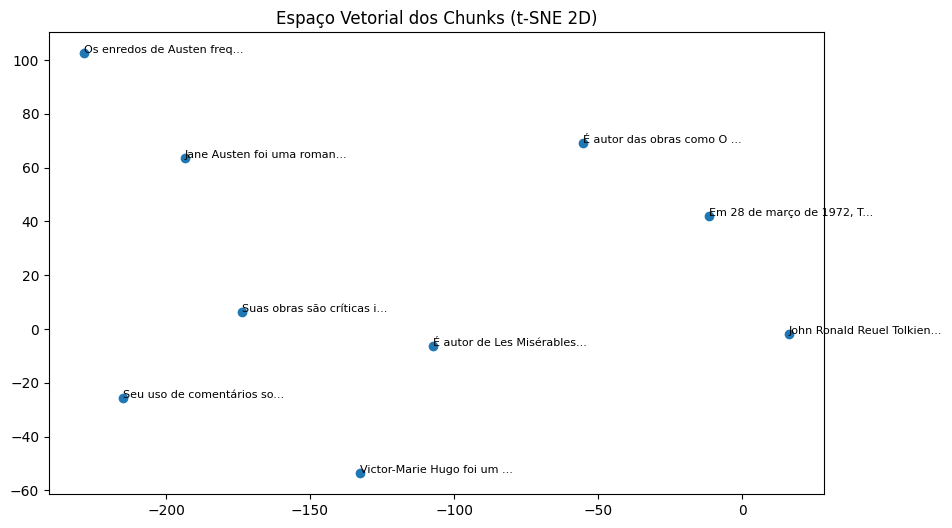

In [81]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import TSNE
import matplotlib.pyplot as plt

X = np.vstack(df["embedding"].values)

# Use t-SNE instead of PCA
ts = TSNE(n_components=2, random_state=42, perplexity=5) # Added random_state for reproducibility and fixed perplexity
X2 = ts.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1])

for i, txt in enumerate(df["sentence"]):
    plt.annotate(txt[:25] + ("..." if len(txt) > 25 else ""), (X2[i, 0], X2[i, 1]), fontsize=8)

plt.title("Espaço Vetorial dos Chunks (t-SNE 2D)") # Update title
plt.show()

## 10) Experimentos

Tente rodar as células abaixo e discutir os resultados.

- O que acontece se `top_k = 1`?
- E se aumentarmos para `top_k = 5`?
- Faça uma pergunta fora do domínio da base (para ver como o sistema se comporta).
- Modifique os documentos e observe o impacto na resposta.


# Nova seção

Quando top_k=1 , o contexto é baseado somente no primeiro documentado retornado, de maior similaridade com a query. A resposta foi correta, contendo o primeiro documento retornado.

Quando top_k=5, o contexto é formado com os 5 primeiros documentos de maior similaridade com a query.